For my project, I will try to combine a CNN and an RNN model like in the paper described in my projet proposal, as the model described was very accurate.
Combining these two types of neural network will enable me to exploit their respective strengths: CNNs are effective at extracting local patterns, while RNNs capture sequential order and contextual information. I will use the architecture from the paper, with some simplifications, to make the implementation easier and better suited to my level. A diagram of the architecture is in 1.

First the dataset is cleaned and tokenized. Then padding is added (since the CNN can only process inputs of the same lenght) and an embedding layer is added to focus on politically meaningful words. The data are then run through four neural networks in parallel: three CNNs with different filter sizes (2, 3 and 4) to detect bigrams, trigrams and quadrigrams, and an LSTM to process word order. The outputs of CNNs and LSTM layers are then run through a max pooling function to focus on the most important features detected. The outputs of CNNs and LSTM layers are then concatenated into a vector, which passes through two fully connected layers for feature refinement and a dropout layer to prevent overfitting. Finally, a softmax layer computes the final probabilities for each political party.

## Data loading, spliting, and tokenazing

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#if executed in a collab section
from google.colab import files
uploaded = files.upload('congress_tweets_dataset_cleaned.parquet')


In [ ]:
#for google collab
df = pd.read_parquet('/content/congress_tweets_dataset_cleaned.parquet/congress_tweets_dataset_cleaned.parquet')

In [13]:
#if executed locally on VScode
df = pd.read_parquet('congress_tweets_dataset_cleaned.parquet')


In [17]:
#Load and split the Data

# We use 75% for training, 10% for validation and 15% for testing and take the most recents tweets for testing

#Ensure the time column is in datetime format
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').reset_index(drop=True)

train_ratio = 0.75
validation_ratio = 0.85

# Split each party's data chronologically
# This ensures that for BOTH 'D' and 'R', the last 25% are used for testing (so we keep the same proportion of republicain and democrat tweets in both sets)

test_list = []
temp_train_val_list = []  #I don't want the validation set to have more recent tweets than the training set

for label in ['D', 'R']:
    party_df = df[df['label'] == label]

    # Calculate the split point (index)
    split_idx = int(len(party_df) * validation_ratio)

    # Split: first 85% to train+validation, last 15% to test
    temp_train_val_list.append(party_df.iloc[:split_idx])
    test_list.append(party_df.iloc[split_idx:])

# Combine the splits back into final DataFrames
df_train_val = pd.concat(temp_train_val_list)
df_test = pd.concat(test_list)

# Shuffle the training and test/val data (because I want the most recent tweets for testing but I want validation and training to be randomly sampled from the rest of the data)
df_train_val = df_train_val.sample(frac=1, random_state=42).reset_index(drop=True)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

#creating the validation and train set and making sure to keep the same R/D ratio in both sets
train_list = []
validation_list = []

for label in ['D', 'R']:
    party_df = df_train_val[df_train_val['label'] == label]

    # Calculate the split point (index)
    split_idx = int(len(party_df) * (train_ratio/validation_ratio))

    # Split: 75/85% of train and 10/85% of validation
    train_list.append(party_df.iloc[:split_idx])
    validation_list.append(party_df.iloc[split_idx:])

# Combine the splits back into final DataFrames
df_train = pd.concat(train_list)
df_validation = pd.concat(validation_list)

# We split the features and the labels
X_train, y_train = df_train['text'], df_train['label']
X_val, y_val = df_validation['text'], df_validation['label']
X_test, y_test = df_test['text'], df_test['label']

# Verification
print(f"Training set size: {len(X_train)} (Ending at {df_train['time'].max()})")
print(f"Validation set size: {len(X_val)} (Ending at {df_validation['time'].max()})")
print(f"Test set size: {len(X_test)} (Starting from {df_test['time'].min()})")
print(f"\nLabel distribution in Test set:\n{y_test.value_counts(normalize=True)}")

Training set size: 3264205 (Ending at 2022-07-28 05:52:12+00:00)
Validation set size: 435228 (Ending at 2022-07-28 04:58:45+00:00)
Test set size: 652842 (Starting from 2022-05-24 15:20:42+00:00)

Label distribution in Test set:
label
D    0.589824
R    0.410176
Name: proportion, dtype: float64


Preparation of the data (tokenization and creation of dataloaders)

In [6]:
import torch
from collections import Counter
import numpy as np

In [18]:
label_map = {'R': 0, 'D': 1}
y_train_num = y_train.map(label_map).values
y_val_num = y_val.map(label_map).values
y_test_num = y_test.map(label_map).values

# Tokenization
#We keep capital letters and punctuation

def tokenize(text):
    return str(text).split()

#construction of a vocabulary dictionary mapping each word to a unique index.
word_counts = Counter()
for text in X_train:
    word_counts.update(tokenize(text))

#to reduce noise, we ignore words that appear less than 20 times in the training set and we add special tokens for padding and unknown words.
min_freq = 50
vocab = {'<PAD>': 0, '<UNK>': 1}

for word, count in word_counts.items():
    if count >= min_freq:
        vocab[word] = len(vocab)

print(f"Vocabulary size : {len(vocab)} words.")


Vocabulary size : 68899 words.


80th percentile of tweet lengths: 45.0 words
90th percentile of tweet lengths: 51.0 words


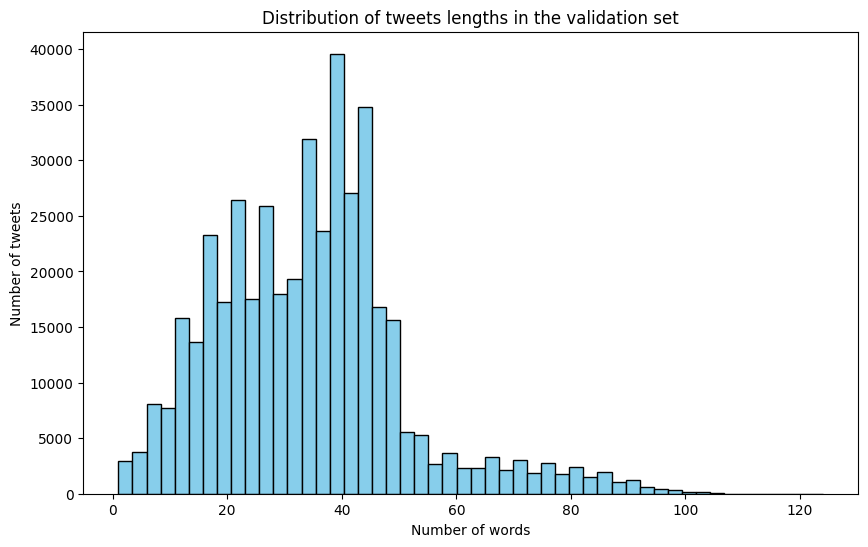

In [5]:
lengths = [len(tokenize(tweet)) for tweet in X_val]

df_lengths = pd.Series(lengths)

p80 = np.percentile(lengths, 80)
p90 = np.percentile(lengths, 90)
print(f"80th percentile of tweet lengths: {p80} words")
print(f"90th percentile of tweet lengths: {p90} words")

plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of tweets lengths in the validation set')
plt.xlabel('Number of words')
plt.ylabel('Number of tweets')
plt.show()

In [10]:
# Padding and text encoding

MAX_LEN = 50 #fixed lenght for the tweets, determined using the distribution of tweet lengths in the validation set, that allows to keep most of the tweets without too much noise and reduce the computational cost of the model

def encode_text(text):
    tokens = tokenize(text)
    #we replace each word by its index or by the index of <UNK> if it is unknown
    encoded = [vocab.get(word, vocab['<UNK>']) for word in tokens]

    #if the encoded tweet is shorter than MAX_LEN, we pad it with the index <PAD> until it reaches the correct lenght, otherwise we truncate it to MAX_LEN
    if len(encoded) < MAX_LEN:
        encoded += [vocab['<PAD>']] * (MAX_LEN - len(encoded))
    else:
        encoded = encoded[:MAX_LEN]

    return encoded

In [19]:
#the training dataset (after tokenization) is too big to be directly converted in a tensor so we have to use a class
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, TensorDataset

class TweetDataset(Dataset):
    """because encoding all the tweet at once was too big for the memory, now that I reduced max_len at 50 so my code can run faster, I don't need the classe anymore"""
    def __init__(self, texts, labels):
        self.texts = texts.values
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        #we only encode the text of the tweet that we want to use, so we don't have to encode the whole dataset at once and we can use it with a DataLoader that will create batches for us
        encoded = encode_text(text)

        return torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long)
"""
train_dataset = TweetDataset(X_train, y_train_num)
val_dataset = TweetDataset(X_val, y_val_num)
test_dataset = TweetDataset(X_test, y_test_num)"""


X_train_tensor = torch.tensor([encode_text(text) for text in X_train], dtype=torch.long)
X_val_tensor = torch.tensor([encode_text(text) for text in X_val], dtype=torch.long)
X_test_tensor = torch.tensor([encode_text(text) for text in X_test], dtype=torch.long)

y_train_tensor = torch.tensor(y_train_num, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_num, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_num, dtype=torch.long)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

#I use smaller dataset to run the code faster while adjusting the hyperparameters, in the final version I will use the whole dataset
#with this purpose in mind, the vocabulary is built on the whole training set

train_size = int(0.2 * len(X_train_tensor)) #20% of the training set
val_size = int(0.2 * len(X_val_tensor)) #20% of the validation set


idx_train, _ = train_test_split(range(len(train_dataset)), train_size=train_size, stratify=y_train_num, random_state=42)
small_train_dataset = torch.utils.data.Subset(train_dataset, idx_train)

idx_val, _ = train_test_split(range(len(val_dataset)), train_size=val_size, stratify=y_val_num, random_state=42)
small_val_dataset = torch.utils.data.Subset(val_dataset, idx_val)

print(f"Small training set size: {len(small_train_dataset)}")   
print(f"Small validation set size: {len(small_val_dataset)}")


Small training set size: 652841
Small validation set size: 87045


## Model Building

In [20]:
import torch.nn as nn
import torch.nn.functional as F

class PoliticalClassifier(nn.Module):
    """Main model, largelly inspired by the paper described in the proposal"""
    def __init__(self, name, vocab_size =len(vocab), embedding_dim=80, hidden_dim=80 , dropout_prob=0.5):
        super(PoliticalClassifier, self).__init__()
        self.name = name
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0) #to avoid empedding the padding filler

        #CNN Branches
        self.conv2 = nn.Conv1d(embedding_dim, 50, kernel_size=2)
        self.conv3 = nn.Conv1d(embedding_dim, 50, kernel_size=3)
        self.conv4 = nn.Conv1d(embedding_dim, 50, kernel_size=4)

        #LSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

        # global max pooling 1d like in the article
        self.pool = nn.AdaptiveMaxPool1d(1)

        # Fully connected layers for classification
        combined_dim = 150 + hidden_dim
        self.fc1 = nn.Linear(combined_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc_out = nn.Linear(32, 2)

    def forward(self, text):
        embedded = self.embedding(text) # [batch, seq_len, emb_dim]

        # LSTM + Pooling
        lstm_out, _ = self.lstm(embedded)
        # On permute pour le pooling: [batch, hidden_dim, seq_len]
        lstm_feature = self.pool(lstm_out.permute(0, 2, 1)).squeeze(2)

        #  CNN + Pooling
        embedded_cnn = embedded.permute(0, 2, 1)
        x2 = self.pool(F.relu(self.conv2(embedded_cnn))).squeeze(2)
        x3 = self.pool(F.relu(self.conv3(embedded_cnn))).squeeze(2)
        x4 = self.pool(F.relu(self.conv4(embedded_cnn))).squeeze(2)

        # Concatenation
        combined = torch.cat((x2, x3, x4, lstm_feature), dim=1)

        # Dense Layers
        x = self.dropout(combined)
        x = F.relu(self.fc1(x))
        #x = self.dropout(x) #dropout here for model 1 and 2
        x = F.relu(self.fc2(x))

        # Output
        logits = self.fc_out(x)
        return logits

In [21]:
def get_model_name(name, batch_size, learning_rate, hidden_dim, embedding_dim, dropout_prob, epoch):
    path = "model_{0}_bs{1}_lr{2}_hidden{3}_embedding{4}_dropout{5}_epoch{6}".format(name, batch_size, learning_rate, hidden_dim, embedding_dim, dropout_prob, epoch)
    return path


def get_accuracy(model, train=False,small=False):
    model.eval() #in order not to have dropout
    if small : 
        if train:
            data = small_train_dataset
        else:
            data = small_val_dataset
    else :
        if train:
            data = train_dataset
        else:
            data = val_dataset

    correct = 0
    total = 0
    with torch.no_grad():
        for text, labels in torch.utils.data.DataLoader(data, batch_size=128):
            #############################################
            # To Enable GPU Usage
            if torch.cuda.is_available():
                text = text.cuda()
                labels = labels.cuda()
            #############################################
            output = model(text)
            #select index with maximum prediction score
            pred = output.max(1, keepdim=True)[1]
            correct += pred.eq(labels.view_as(pred)).sum().item()
            total += text.shape[0]
    return correct / total

In [22]:
def train(model, data, batch_size=128, learning_rate=0.001, hidden_dim=80, embedding_dim=80, dropout_prob=0.5, num_epochs=10,print_stat=True,small=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    train_loader = torch.utils.data.DataLoader(data, batch_size=batch_size,shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,weight_decay=1e-5)

    iters, losses, train_acc, val_acc = [], [], [], []

    # training
    n = 0 # the number of iterations
    for epoch in range(num_epochs):
        model.train() #in order to have dropout during training

        for text, labels in iter(train_loader):

            #To Enable GPU Usage
            text, labels = text.to(device), labels.to(device)

            out = model(text)             # forward pass
            loss = criterion(out, labels) # compute the total loss
            loss.backward()               # backward pass (compute parameter updates)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) #to avoid exploding gradients, we clip the gradients to a maximum norm of 1.0
            optimizer.step()              # make the updates for each parameter
            optimizer.zero_grad()         # a clean up step for PyTorch

          # save the current training information
            iters.append(n)
            losses.append(float(loss.item()))             # compute *average* loss
            n += 1

        train_acc.append(get_accuracy(model, train=True, small=small))  # compute training accuracy at the end of the epoch
        val_acc.append(get_accuracy(model, train=False, small=small))  # compute validation accuracy

        print ("Epoch %d Finished. " % epoch )

    if print_stat:
      # plotting
      plt.title("Training Curve")
      plt.plot(iters, losses, label="Train")
      plt.xlabel("Iterations")
      plt.ylabel("Loss")
      plt.show()

      plt.title("Training Curve")
      plt.plot(range(num_epochs), train_acc, label="Training")
      plt.plot(range(num_epochs), val_acc, label="Validation")
      plt.xlabel("Iterations")
      plt.ylabel("Validation Accuracy")
      plt.legend(loc='best')
      plt.show()

      print("Final Training Accuracy: {}".format(train_acc[-1]))
      print("Final Validation Accuracy: {}".format(val_acc[-1]))

      # Save the current model (checkpoint) to a file
      model_path = get_model_name(model.name, batch_size, learning_rate, hidden_dim, embedding_dim, dropout_prob, epoch)
      torch.save(model.state_dict(), model_path)



## Sanity Checking

In [24]:
#We check that the model is able to memorize the data on a small dataset

from torch.utils.data import Subset
debug_data = Subset(train_dataset, list(range(42)))
model = PoliticalClassifier("small_model")
train(model, debug_data, print_stat = False)


Epoch 0 Finished. 
Epoch 1 Finished. 
Epoch 2 Finished. 
Epoch 3 Finished. 
Epoch 4 Finished. 
Epoch 5 Finished. 
Epoch 6 Finished. 
Epoch 7 Finished. 
Epoch 8 Finished. 
Epoch 9 Finished. 


In [ ]:
#obtain accuracy on 42 samples
correct = 0
total = 0
for txt, labels in torch.utils.data.DataLoader(debug_data, batch_size=42):
    if torch.cuda.is_available():
        txt = txt.cuda()
        labels = labels.cuda()
    output = model(txt)
    #select index with maximum prediction score
    pred = output.max(1, keepdim=True)[1]
    correct += pred.eq(labels.view_as(pred)).sum().item()
    total += txt.shape[0]
print('Accuracy on batch of 42: ', correct / total)

Accuracy on batch of 42:  1.0


yay !

Epoch 0 Finished. 
Epoch 1 Finished. 
Epoch 2 Finished. 
Epoch 3 Finished. 
Epoch 4 Finished. 
Epoch 5 Finished. 
Epoch 6 Finished. 
Epoch 7 Finished. 
Epoch 8 Finished. 
Epoch 9 Finished. 


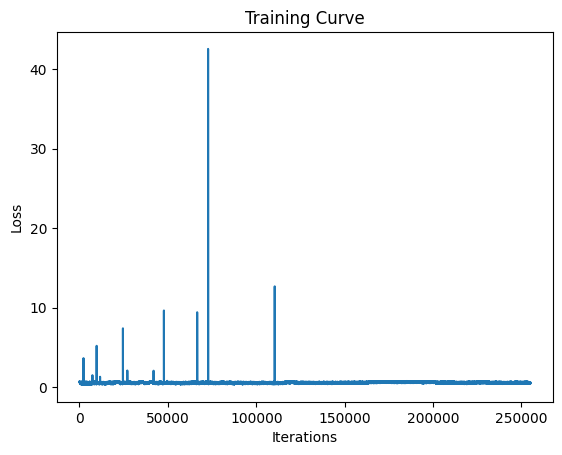

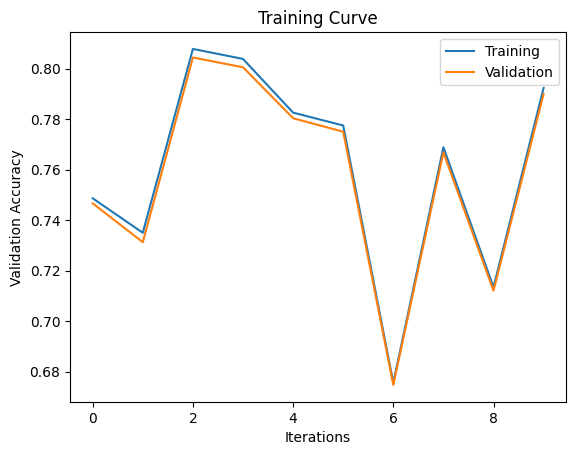

Final Training Accuracy: 0.792322786099525
Final Validation Accuracy: 0.7899216043085463


In [15]:
#Test on the whole dataset
model1 = PoliticalClassifier("model1",)
train(model1, train_dataset, batch_size=128, num_epochs=10)

Epoch 0 Finished. 
Epoch 1 Finished. 
Epoch 2 Finished. 


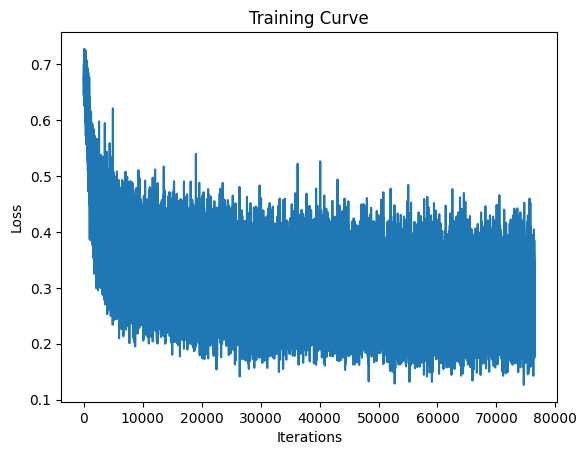

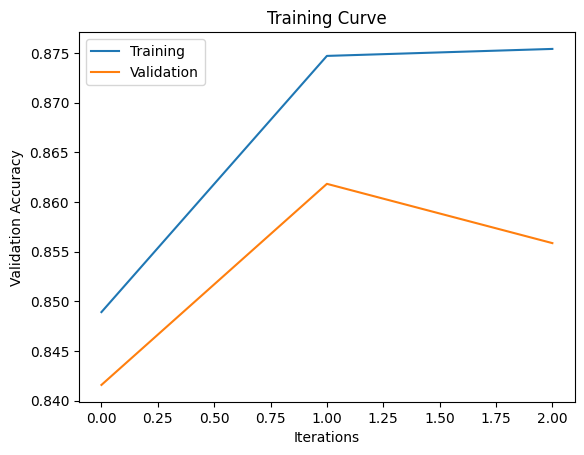

Final Training Accuracy: 0.8754039651308665
Final Validation Accuracy: 0.855850266986499


In [29]:
#Test on the whole dataset
model2 = PoliticalClassifier("model2",)
train(model2, train_dataset, batch_size=128, num_epochs=3,learning_rate=0.001)

Epoch 0 Finished. 
Epoch 1 Finished. 
Epoch 2 Finished. 
Epoch 3 Finished. 
Epoch 4 Finished. 
Epoch 5 Finished. 
Epoch 6 Finished. 
Epoch 7 Finished. 
Epoch 8 Finished. 
Epoch 9 Finished. 


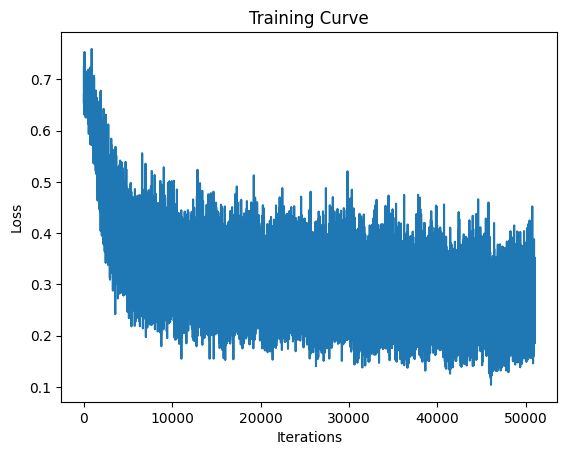

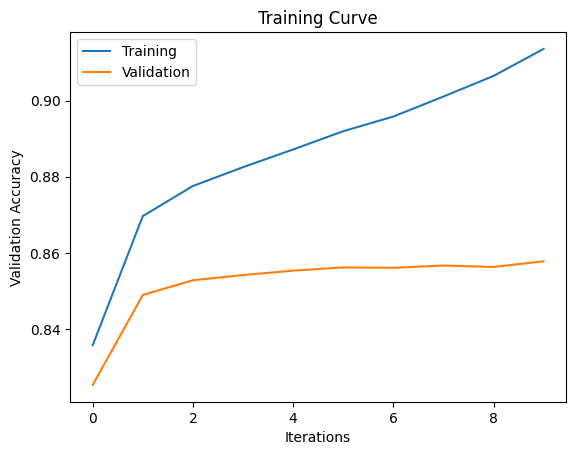

Final Training Accuracy: 0.9136083671215502
Final Validation Accuracy: 0.8577862025389167


In [59]:
model3 = PoliticalClassifier("model3",)
#dropout moved, + added weight decay
train(model3, small_train_dataset, batch_size=128, num_epochs=10,learning_rate=0.0005,small=True)

Epoch 0 Finished. 
Epoch 1 Finished. 
Epoch 2 Finished. 
Epoch 3 Finished. 
Epoch 4 Finished. 
Epoch 5 Finished. 
Epoch 6 Finished. 
Epoch 7 Finished. 
Epoch 8 Finished. 
Epoch 9 Finished. 


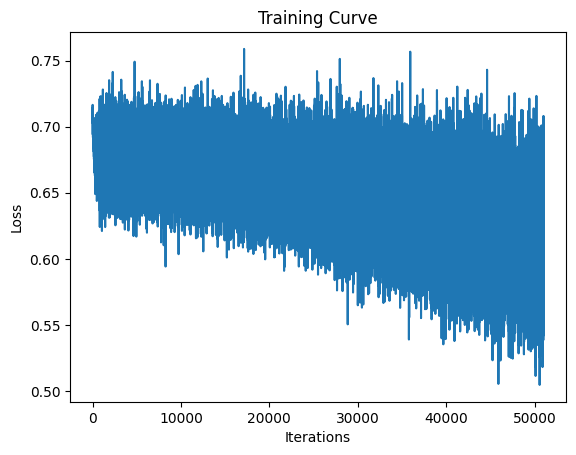

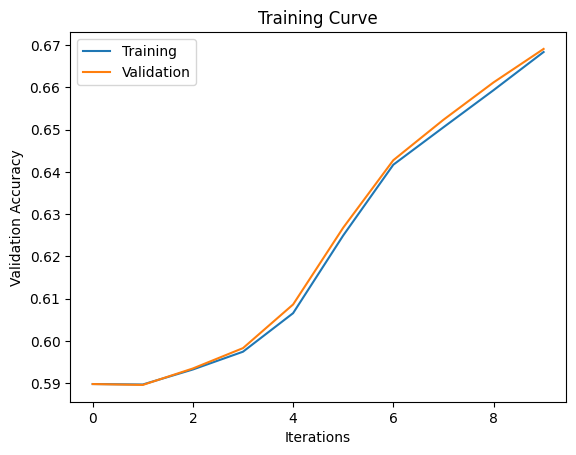

Final Training Accuracy: 0.6683847981361465
Final Validation Accuracy: 0.6691136768338216


In [11]:
model4 = PoliticalClassifier("model4",)
#dropout moved, + added weight decay
train(model4, small_train_dataset, batch_size=128, num_epochs=10,learning_rate=0.00001,small=True)

Epoch 0 Finished. 
Epoch 1 Finished. 
Epoch 2 Finished. 
Epoch 3 Finished. 
Epoch 4 Finished. 
Epoch 5 Finished. 
Epoch 6 Finished. 
Epoch 7 Finished. 
Epoch 8 Finished. 
Epoch 9 Finished. 
Epoch 10 Finished. 
Epoch 11 Finished. 
Epoch 12 Finished. 
Epoch 13 Finished. 
Epoch 14 Finished. 
Epoch 15 Finished. 
Epoch 16 Finished. 
Epoch 17 Finished. 
Epoch 18 Finished. 
Epoch 19 Finished. 


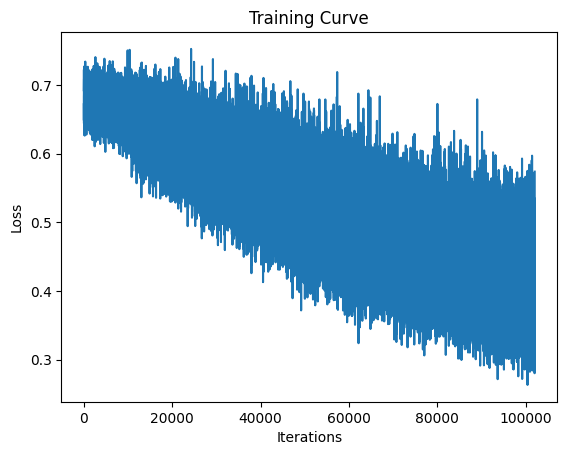

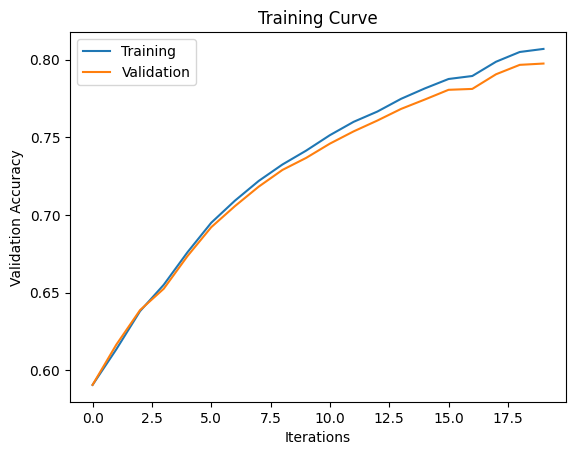

Final Training Accuracy: 0.8068518980885085
Final Validation Accuracy: 0.7974381067264059


In [13]:
model4 = PoliticalClassifier("model4",)
#dropout moved, + added weight decay
train(model4, small_train_dataset, batch_size=128, num_epochs=20,learning_rate=0.00002,small=True)

Epoch 0 Finished. 
Epoch 1 Finished. 
Epoch 2 Finished. 
Epoch 3 Finished. 
Epoch 4 Finished. 
Epoch 5 Finished. 
Epoch 6 Finished. 
Epoch 7 Finished. 
Epoch 8 Finished. 
Epoch 9 Finished. 
Epoch 10 Finished. 
Epoch 11 Finished. 
Epoch 12 Finished. 
Epoch 13 Finished. 
Epoch 14 Finished. 
Epoch 15 Finished. 
Epoch 16 Finished. 
Epoch 17 Finished. 
Epoch 18 Finished. 
Epoch 19 Finished. 
Epoch 20 Finished. 
Epoch 21 Finished. 
Epoch 22 Finished. 
Epoch 23 Finished. 
Epoch 24 Finished. 
Epoch 25 Finished. 
Epoch 26 Finished. 
Epoch 27 Finished. 
Epoch 28 Finished. 
Epoch 29 Finished. 
Epoch 30 Finished. 
Epoch 31 Finished. 
Epoch 32 Finished. 
Epoch 33 Finished. 
Epoch 34 Finished. 
Epoch 35 Finished. 
Epoch 36 Finished. 
Epoch 37 Finished. 
Epoch 38 Finished. 
Epoch 39 Finished. 


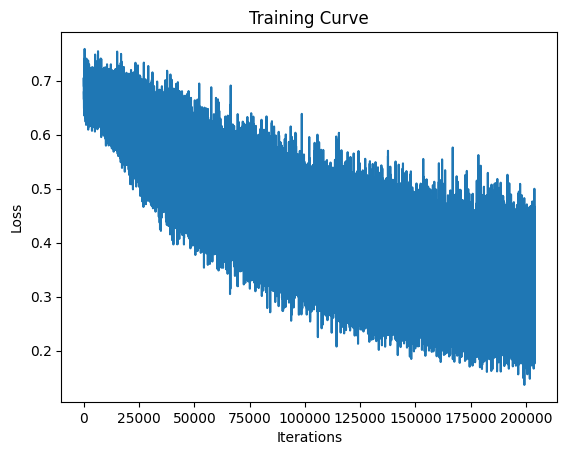

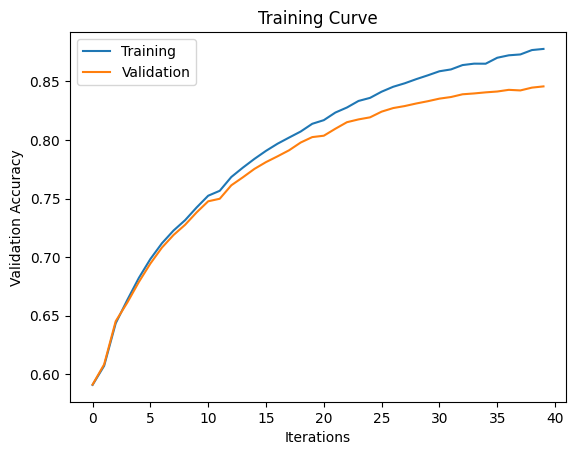

Final Training Accuracy: 0.8778094513059076
Final Validation Accuracy: 0.8458153828479522


In [14]:
model5 = PoliticalClassifier("model5",)
#dropout moved, + added weight decay
train(model5, small_train_dataset, batch_size=128, num_epochs=40,learning_rate=0.00002,small=True)

In [39]:
#Qualitative result for the report, we test the prediction that the model makes for simple poltical or neutral words
best_model = PoliticalClassifier("best")
model_path = get_model_name("model5", batch_size=128, learning_rate=0.00002, hidden_dim=80, embedding_dim=80, dropout_prob=0.5, epoch=39)
state = torch.load(model_path)
best_model.load_state_dict(state)

test_tweets = ["Trump", "Biden", "I am pro-choice", "I love chocolate", "I don't like Trump", "I like Trump","I don't like Biden", "I like Biden"]

test_df = pd.DataFrame(test_tweets, columns=["tweet"])
test_tweet_encoded = torch.tensor([encode_text(text) for text in test_df["tweet"]], dtype=torch.long)

best_model.eval()
with torch.no_grad():
    logits = best_model(test_tweet_encoded)
    probability = F.softmax(logits, dim=1)

test_df["Proba Rep"] = probability[:, 0]
test_df["Proba Dem"] = probability[:, 1]

test_df["Prediction"]=test_df.apply(lambda row: "Republican" if row["Proba Rep"] > row["Proba Dem"] else "Democrat", axis=1)

display(test_df)

,tweet,Proba Rep,Proba Dem,Prediction
0,Trump,0.208414,0.791586,Democrat
1,Biden,0.933354,0.066646,Republican
2,I am pro-choice,0.278213,0.721787,Democrat
3,I love chocolate,0.375759,0.624241,Democrat
4,I don't like Trump,0.149770,0.850230,Democrat
5,I like Trump,0.183858,0.816142,Democrat
6,I don't like Biden,0.916651,0.083349,Republican
7,I like Biden,0.949971,0.050029,Republican
